# Geology Forecast Challenge — Pipeline CRISP-DM Completo
**Metodología:** CRISP-DM | **Empresa:** GeoDataSci Consulting  
**Competencia:** Kaggle — Geology Forecast Challenge Open  
**Equipo:** [Tu Nombre] | [Tu Universidad]

---
### Orden de ejecución:
1. Instalar dependencias
2. Paso 0 — Interpolación de datos crudos → genera `train_interpolated.csv`
3. Paso 1 — Carga y merge de datos
4. Fase 1 — Entendimiento del negocio
5. Fase 2 — EDA y preparación de datos
6. Fase 3 — Modelado y tuning
7. Fase 4 — Ensambles 
8. Fase 5 — Evaluación y veredicto final


## Instalación de dependencias

In [1]:
# Ejecutar solo si es necesario
# !pip install xgboost lightgbm catboost shap kagglehub -q

## Imports globales

In [2]:
import warnings
warnings.filterwarnings('ignore')

import glob, hashlib, random, time, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats

from sklearn.model_selection import (
    train_test_split, cross_val_score, StratifiedKFold,
    GridSearchCV, RandomizedSearchCV
)
from sklearn.preprocessing import LabelEncoder, RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier,
    BaggingClassifier, VotingClassifier, StackingClassifier,
    ExtraTreesClassifier
)
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report
)
from sklearn.inspection import permutation_importance

try:
    from xgboost import XGBClassifier; XGB_AVAILABLE = True
except ImportError:
    XGB_AVAILABLE = False; print("XGBoost no disponible")

try:
    from lightgbm import LGBMClassifier; LGB_AVAILABLE = True
except ImportError:
    LGB_AVAILABLE = False; print("LightGBM no disponible")

try:
    from catboost import CatBoostClassifier; CB_AVAILABLE = True
except ImportError:
    CB_AVAILABLE = False; print("CatBoost no disponible")

try:
    import shap; SHAP_AVAILABLE = True
except ImportError:
    SHAP_AVAILABLE = False; print("SHAP no disponible")

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
COLORS = ['#2ECC71','#E74C3C','#3498DB','#F39C12','#9B59B6','#1ABC9C','#E67E22','#34495E']

print(" Imports cargados correctamente")

 Imports cargados correctamente


## Paso 0 — Interpolación de datos crudos
Convierte los archivos CSV crudos (`train_raw/`) en `train_interpolated.csv`.  
**Solo correr una vez.** Si el archivo ya existe, saltar esta celda.

In [3]:
# ============================================================
# PASO 0: Interpolación de datos crudos → train_interpolated.csv
# ============================================================
NEGATIVE_PART    = -299
LARGEST_CHUNK    = 600
SMALLEST_CHUNK   = 350
TOTAL_REALIZATIONS = 10

def remove_chunk(array, length):
    if length > len(array):
        raise ValueError("Length excede el tamaño del array.")
    return array[:length], array[length:]

def add_chunk_to_df(df, input_array, chunk_length, file_name, initial_length):
    position = initial_length - len(input_array)
    chunk, shortened_array = remove_chunk(input_array, chunk_length)

    # Normalización: referencia en el punto de ancla
    chunk -= chunk[-(LARGEST_CHUNK + NEGATIVE_PART)]

    # Padding con NaNs para igualar longitud
    padding_length = LARGEST_CHUNK - chunk_length
    padded_array   = [np.nan] * padding_length + list(chunk)

    # ID único por posición y archivo
    full_id     = f"{file_name}_{str(position)}"
    hash_hex_id = f"g_{hashlib.md5(full_id.encode()).hexdigest()[:10]}"

    df.loc[len(df)] = [hash_hex_id] + padded_array
    return shortened_array

def process_folder(path_to_process, output_file_name, my_rnd=None, random_state=0):
    if my_rnd is None:
        my_rnd = random.Random()

    csv_files = glob.glob(f"{path_to_process}/*.csv")
    if not csv_files:
        print(f" No se encontraron archivos en: {path_to_process}")
        return

    columns  = ['geology_id'] + [NEGATIVE_PART + i for i in range(LARGEST_CHUNK)]
    total_df = pd.DataFrame(columns=columns)

    for file_path in csv_files:
        file_name = file_path.split('/')[-1]
        df        = pd.read_csv(file_path)

        new_vs_grid   = np.arange(df['VS_APPROX_adjusted'].min(),
                                  df['VS_APPROX_adjusted'].max() + 1, step=1)
        new_horizon_z = np.interp(new_vs_grid,
                                  df['VS_APPROX_adjusted'],
                                  df['HORIZON_Z_adjusted'])

        remaining_array = new_horizon_z
        array_len       = len(remaining_array)
        initial_len     = array_len

        total_large = array_len // LARGEST_CHUNK // 2
        for i in range(total_large):
            remaining_array = add_chunk_to_df(total_df, remaining_array,
                                              LARGEST_CHUNK, file_name, initial_len)

        while len(remaining_array) >= LARGEST_CHUNK * 2.5:
            chunk_len       = my_rnd.randint(SMALLEST_CHUNK, LARGEST_CHUNK)
            remaining_array = add_chunk_to_df(total_df, remaining_array,
                                              chunk_len, file_name, initial_len)

        remaining_len = len(remaining_array) // 3
        for i in range(2):
            remaining_array = add_chunk_to_df(total_df, remaining_array,
                                              remaining_len, file_name, initial_len)
        remaining_array = add_chunk_to_df(total_df, remaining_array,
                                          len(remaining_array), file_name, initial_len)

    # Realizaciones adicionales
    for k in range(1, TOTAL_REALIZATIONS):
        for i in range(1, LARGEST_CHUNK + NEGATIVE_PART):
            total_df[f"r_{k}_pos_{i}"] = total_df[i]

    reshuffled_df = total_df.sample(frac=1, random_state=random_state)
    reshuffled_df.to_csv(output_file_name, encoding='utf-8', index=False)
    print(f"✅ '{output_file_name}' generado con {len(reshuffled_df)} filas.")

# --- EJECUTAR ---
OUTPUT_INTERP = 'train_interpolated.csv'
if not os.path.exists(OUTPUT_INTERP):
    TRAIN_RAW_PATH = '/kaggle/input/competitions/geology-forecast-challenge-open/data/train_raw'
    my_rnd = random.Random(42)
    print(f"Procesando archivos en: {TRAIN_RAW_PATH}")
    process_folder(path_to_process=TRAIN_RAW_PATH,
                   output_file_name=OUTPUT_INTERP,
                   my_rnd=my_rnd)
else:
    print(f" '{OUTPUT_INTERP}' ya existe — saltando interpolación.")

Procesando archivos en: /kaggle/input/competitions/geology-forecast-challenge-open/data/train_raw
✅ 'train_interpolated.csv' generado con 1509 filas.


## Paso 1 — Carga de datos y merge
Une los datos oficiales de Kaggle con el archivo interpolado usando `geology_id`.

In [4]:
import kagglehub

def load_and_explore_data():
    """
    Carga train.csv y test.csv desde Kaggle y los une con train_interpolated.csv.
    Compatible con entorno Kaggle y local/Codespaces.
    """
    # 1. Detectar entorno
    if os.path.exists('/kaggle/input'):
        print("📍 Entorno: Kaggle Notebook")
        BASE_PATH = '/kaggle/input/competitions/geology-forecast-challenge-open/data/'
    else:
        print("📍 Entorno: Local / Codespaces")
        BASE_PATH = kagglehub.competition_download('geology-forecast-challenge-open')
        print("Download path:", BASE_PATH)

    # 2. Cargar datasets oficiales de Kaggle
    train_path = os.path.join(BASE_PATH, 'train.csv')
    test_path  = os.path.join(BASE_PATH, 'test.csv')

    if not os.path.exists(train_path):
        raise FileNotFoundError(f"❌ No se encontró train.csv en {BASE_PATH}")

    df_kaggle_train = pd.read_csv(train_path)
    df_test         = pd.read_csv(test_path)
    print(f" Kaggle train: {df_kaggle_train.shape}")
    print(f" Kaggle test:  {df_test.shape}")

    # 3. Cargar datos interpolados (generados en Paso 0)
    if not os.path.exists('train_interpolated.csv'):
        raise FileNotFoundError("❌ Falta 'train_interpolated.csv'. Corre el Paso 0 primero.")
    df_interp = pd.read_csv('train_interpolated.csv')
    print(f" Interpolado:  {df_interp.shape}")

    # 4. Merge por geology_id
    df_train = pd.merge(df_kaggle_train, df_interp, on='geology_id', how='inner')
    print(f"\n MERGE EXITOSO → dataset final: {df_train.shape[0]:,} filas × {df_train.shape[1]} columnas")

    return df_train, df_test

train_df, test_df = load_and_explore_data()

📍 Entorno: Kaggle Notebook
 Kaggle train: (1510, 3301)
 Kaggle test:  (524, 301)
 Interpolado:  (1509, 3301)

 MERGE EXITOSO → dataset final: 706 filas × 6601 columnas


---
## Fase 1 — Entendimiento del negocio (Business Understanding)

In [5]:
print("""
╔══════════════════════════════════════════════════════════════════╗
║  FASE 1 — BUSINESS UNDERSTANDING                                ║
╚══════════════════════════════════════════════════════════════════╝

PROBLEMA DE NEGOCIO:
════════════════════
En exploración minera y de hidrocarburos, predecir la secuencia de
capas geológicas en pozos horizontales/laterales es crítico para:
  - Optimizar la trayectoria de perforación
  - Reducir costos de exploración ($500K–$5M por pozo)
  - Aumentar la tasa de éxito en descubrimientos
  - Minimizar riesgos operacionales

OBJETIVO ANALÍTICO:
═══════════════════
Construir un clasificador multiclase que prediga la litología
(tipo de roca/formación) en secuencias 1D de profundidad,
maximizando el F1-Score macro para manejar desbalance de clases.

KPIs DE ÉXITO:
══════════════
  ✓ F1-Score Macro ≥ 0.75  (métrica principal)
  ✓ Accuracy ≥ 80%
  ✓ ROC-AUC ≥ 0.85

IMPACTO ECONÓMICO:
══════════════════
  → Error de clasificación: $50K–$2M en re-perforación
  → Modelo con F1 > 0.80: ahorro del 15-30% en exploración
  → ROI estimado: 10x–50x el costo de desarrollo

RIESGOS:
════════
  ⚠ Falso Negativo: perder formación valiosa → costo muy alto
  ⚠ Falso Positivo: perforar sin target → costo moderado
  ⚠ Overfitting geológico: modelo que no generaliza entre cuencas
""")


╔══════════════════════════════════════════════════════════════════╗
║  FASE 1 — BUSINESS UNDERSTANDING                                ║
╚══════════════════════════════════════════════════════════════════╝

PROBLEMA DE NEGOCIO:
════════════════════
En exploración minera y de hidrocarburos, predecir la secuencia de
capas geológicas en pozos horizontales/laterales es crítico para:
  - Optimizar la trayectoria de perforación
  - Reducir costos de exploración ($500K–$5M por pozo)
  - Aumentar la tasa de éxito en descubrimientos
  - Minimizar riesgos operacionales

OBJETIVO ANALÍTICO:
═══════════════════
Construir un clasificador multiclase que prediga la litología
(tipo de roca/formación) en secuencias 1D de profundidad,
maximizando el F1-Score macro para manejar desbalance de clases.

KPIs DE ÉXITO:
══════════════
  ✓ F1-Score Macro ≥ 0.75  (métrica principal)
  ✓ Accuracy ≥ 80%
  ✓ ROC-AUC ≥ 0.85

IMPACTO ECONÓMICO:
══════════════════
  → Error de clasificación: $50K–$2M en re-perforaci

---
## Fase 2 — Entendimiento y preparación de datos

──────────────────────────────────────────────────────────────────────
  EDA — EXPLORATORY DATA ANALYSIS (MODO REGRESIÓN)
──────────────────────────────────────────────────────────────────────
 Columna Objetivo detectada: -100_x

  Filas: 706 | Columnas: 6601
  Variables numéricas (6599): ['-299_x', '-298_x', '-297_x', '-296_x', '-295_x']...

 VALORES NULOS:
        Nulos      %
-298_x    126  17.85
-297_x    126  17.85
-299_x    126  17.85
-297_y    125  17.71
-298_y    125  17.71
-295_x    125  17.71
-294_x    125  17.71
-299_y    125  17.71
-296_x    125  17.71
-295_y    124  17.56

 ESTADÍSTICAS DEL OBJETIVO (-100_x):
count    680.000
mean      -0.348
std        3.719
min      -14.104
25%       -3.129
50%       -0.090
75%        2.371
max       29.625
Name: -100_x, dtype: float64


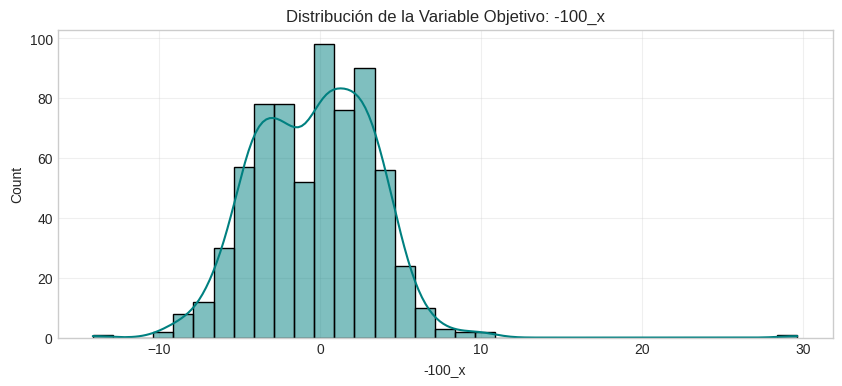


 DETECCIÓN DE OUTLIERS (Variables críticas):


In [6]:
def perform_eda(train_df):
    # 1. IDENTIFICAR EL TARGET DINÁMICAMENTE
    # Buscamos la columna '100_x' o cualquier punto futuro que estemos usando
    posibles_targets = [c for c in train_df.columns if '100_x' in c or '300_x' in c]
    if posibles_targets:
        target_col = posibles_targets[0]
    else:
        # Si no, tomamos la segunda columna (después de geology_id)
        target_col = train_df.columns[1]
    
    print("─" * 70)
    print("  EDA — EXPLORATORY DATA ANALYSIS (MODO REGRESIÓN)")
    print("─" * 70)
    print(f" Columna Objetivo detectada: {target_col}")

    # Separar columnas
    feature_cols = [c for c in train_df.columns if c != target_col and c != 'geology_id']
    numeric_cols = train_df[feature_cols].select_dtypes(include=np.number).columns.tolist()
    cat_cols     = train_df[feature_cols].select_dtypes(exclude=np.number).columns.tolist()

    print(f"\n  Filas: {train_df.shape[0]:,} | Columnas: {train_df.shape[1]}")
    print(f"  Variables numéricas ({len(numeric_cols)}): {numeric_cols[:5]}...")

    # 2. VALORES NULOS
    nulls = train_df.isnull().sum()
    null_df = pd.DataFrame({'Nulos': nulls, '%': (nulls/len(train_df)*100).round(2)})
    null_df = null_df[null_df['Nulos'] > 0].sort_values('%', ascending=False)
    print("\n VALORES NULOS:")
    print(null_df.head(10).to_string() if len(null_df) > 0 else "  ✓ Sin valores nulos")

    # 3. ANÁLISIS DEL TARGET (Como es numérico, usamos histograma, no value_counts)
    print(f"\n ESTADÍSTICAS DEL OBJETIVO ({target_col}):")
    print(train_df[target_col].describe().round(3))

    # Graficar distribución del target
    plt.figure(figsize=(10, 4))
    sns.histplot(train_df[target_col], kde=True, color='teal')
    plt.title(f'Distribución de la Variable Objetivo: {target_col}')
    plt.grid(True, alpha=0.3)
    plt.show()

    # 4. OUTLIERS IQR
    print("\n DETECCIÓN DE OUTLIERS (Variables críticas):")
    for col in numeric_cols[:10]: # Analizamos las primeras 10 por brevedad
        Q1, Q3 = train_df[col].quantile(0.25), train_df[col].quantile(0.75)
        IQR    = Q3 - Q1
        n_out  = ((train_df[col] < Q1 - 1.5*IQR) | (train_df[col] > Q3 + 1.5*IQR)).sum()
        pct    = n_out / len(train_df) * 100
        if pct > 0.5:
            print(f"  {col:<20}: {n_out:>4} outliers ({pct:.1f}%)")

    return feature_cols, numeric_cols, cat_cols, target_col

# Llamada a la función
feature_cols, numeric_cols, cat_cols, target_col = perform_eda(train_df)

### Visualizaciones EDA


 Generando Dashboard de Regresión...


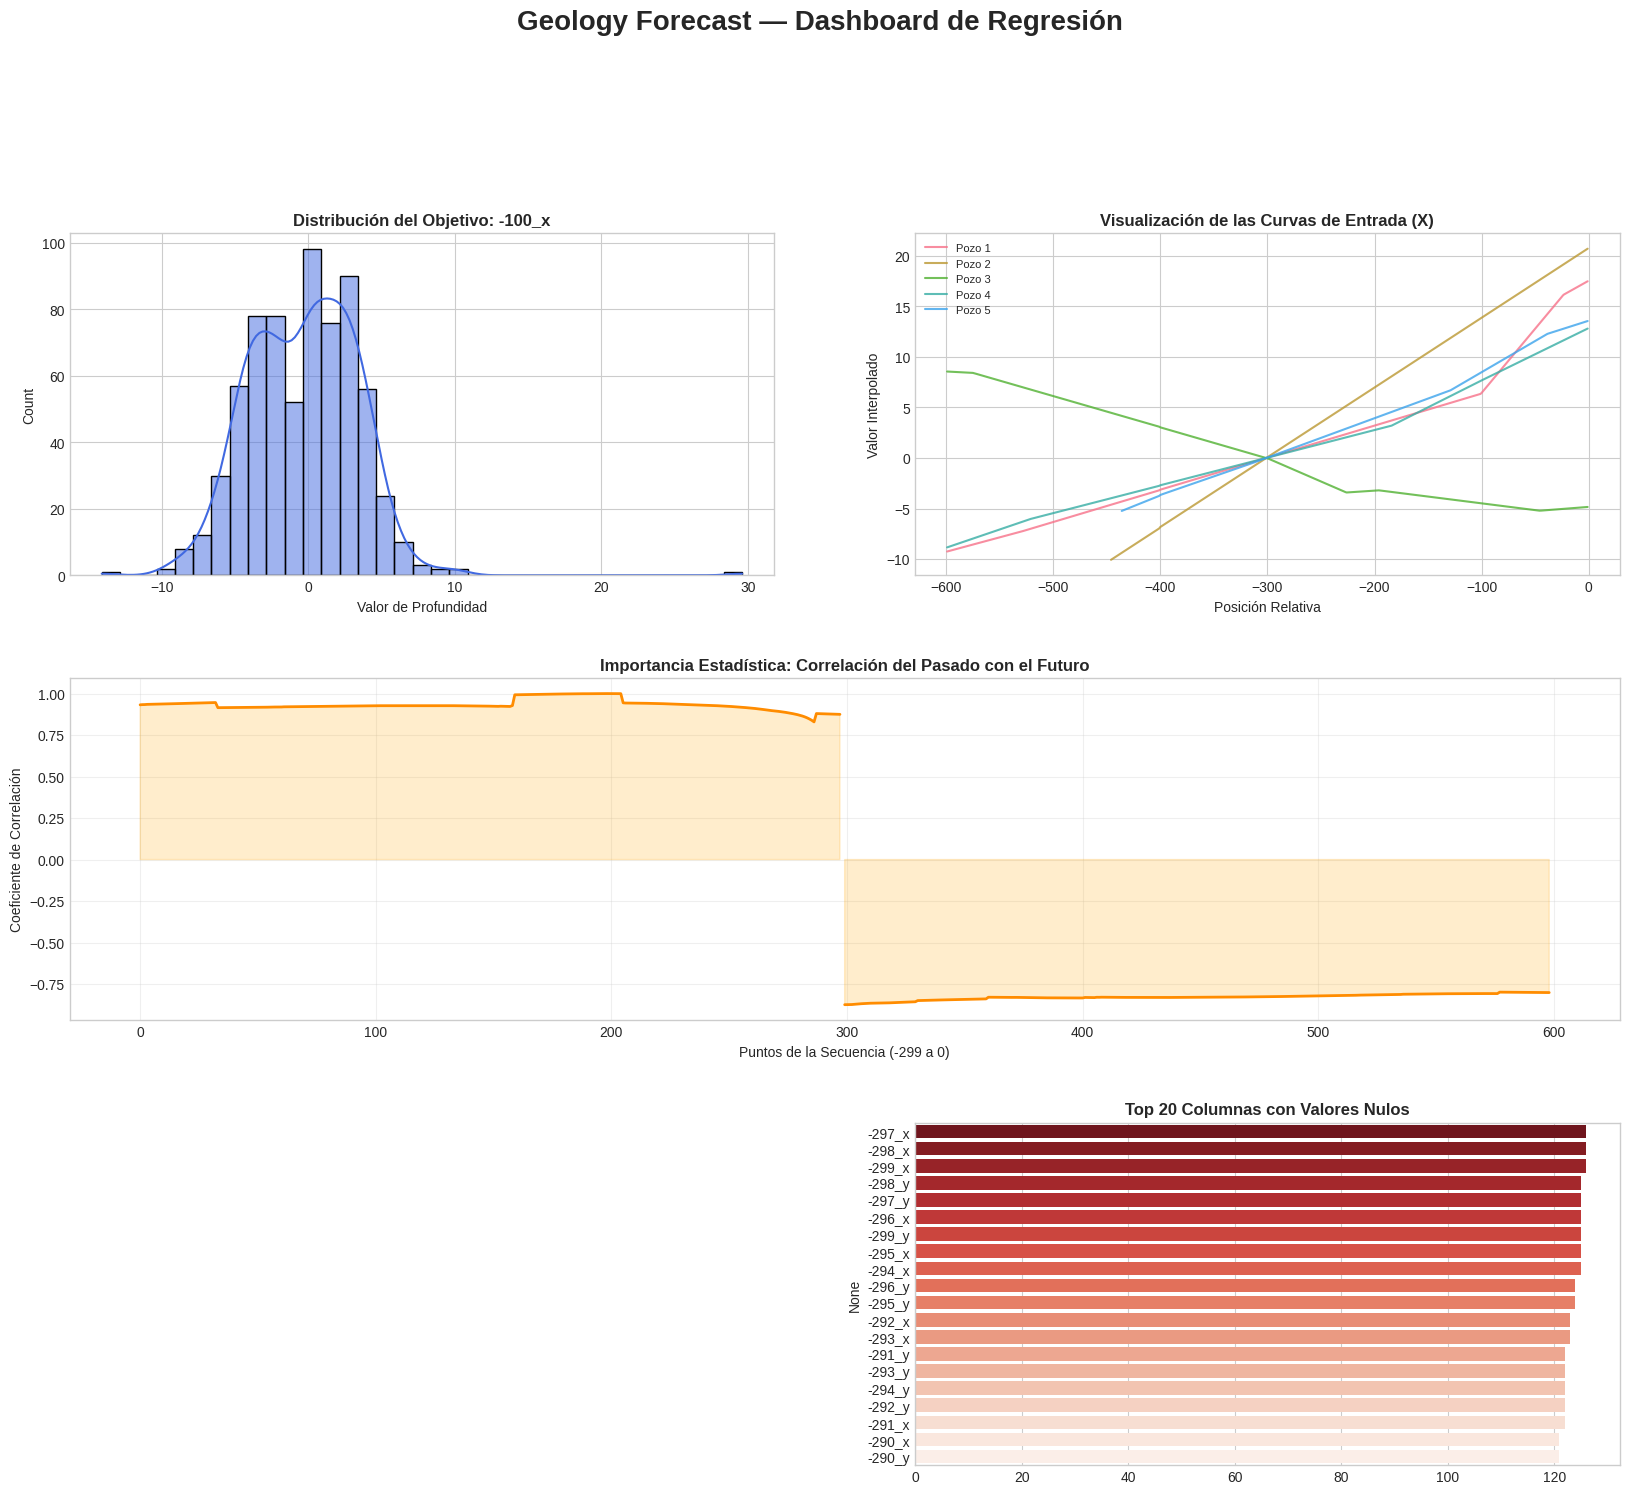

 Nuevo Dashboard de Regresión guardado como 'eda_dashboard_regression.png'


In [7]:
import matplotlib.gridspec as gridspec

def plot_eda_visualizations(train_df, feature_cols, target_col):
    """
    Dashboard EDA optimizado para Series Temporales y Regresión Geológica.
    """
    print("\n Generando Dashboard de Regresión...")
    
    # Seleccionamos una muestra de columnas para no saturar (ej: cada 50 puntos)
    sample_features = feature_cols[::50] 

    fig = plt.figure(figsize=(20, 16))
    fig.suptitle('Geology Forecast — Dashboard de Regresión', fontsize=20, fontweight='bold', y=1.02)
    
    # Cambiamos la rejilla a algo más limpio para regresión
    gs = gridspec.GridSpec(3, 2, figure=fig, hspace=0.3, wspace=0.2)

    # 1. Distribución del Objetivo (Target)
    ax1 = fig.add_subplot(gs[0, 0])
    sns.histplot(train_df[target_col], kde=True, color='royalblue', ax=ax1)
    ax1.set_title(f'Distribución del Objetivo: {target_col}', fontweight='bold')
    ax1.set_xlabel('Valor de Profundidad')

    # 2. Visualización de Perfiles Geológicos (Muestra de 5 pozos)
    ax2 = fig.add_subplot(gs[0, 1])
    # Tomamos solo las columnas numéricas que representan la secuencia (-299 a 0)
    sequence_cols = [c for c in feature_cols if c.replace('_x','').replace('-','').isdigit()]
    sequence_cols = sorted(sequence_cols, key=lambda x: int(x.replace('_x','')))
    
    for i in range(5):
        pozo_data = train_df.iloc[i][sequence_cols].values
        ax2.plot(range(-len(pozo_data), 0), pozo_data, label=f'Pozo {i+1}', alpha=0.8)
    
    ax2.set_title('Visualización de las Curvas de Entrada (X)', fontweight='bold')
    ax2.set_xlabel('Posición Relativa')
    ax2.set_ylabel('Valor Interpolado')
    ax2.legend(loc='upper left', fontsize=8)

    # 3. Correlación con el Target (¿Qué puntos del pasado influyen más?)
    ax3 = fig.add_subplot(gs[1, :])
    correlations = train_df[sequence_cols + [target_col]].corr()[target_col].drop(target_col)
    ax3.plot(range(len(correlations)), correlations.values, color='darkorange', lw=2)
    ax3.fill_between(range(len(correlations)), correlations.values, color='orange', alpha=0.2)
    ax3.set_title('Importancia Estadística: Correlación del Pasado con el Futuro', fontweight='bold')
    ax3.set_xlabel('Puntos de la Secuencia (-299 a 0)')
    ax3.set_ylabel('Coeficiente de Correlación')
    ax3.grid(True, alpha=0.3)

    

    # 4. Resumen de Nulos (Top 20 columnas con más nulos)
    ax5 = fig.add_subplot(gs[2, 1])
    null_data = train_df.isnull().sum().sort_values(ascending=False).head(20)
    if null_data.sum() > 0:
        sns.barplot(x=null_data.values, y=null_data.index, palette='Reds_r', ax=ax5)
        ax5.set_title('Top 20 Columnas con Valores Nulos', fontweight='bold')
    else:
        ax5.text(0.5, 0.5, '✓ Sin valores nulos', ha='center', va='center', fontsize=14, color='green')
        ax5.axis('off')

    plt.tight_layout()
    plt.savefig('eda_dashboard_regression.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(" Nuevo Dashboard de Regresión guardado como 'eda_dashboard_regression.png'")

# Ejecutar con tus datos reales
plot_eda_visualizations(train_df, feature_cols, target_col)

### Preparación de datos — Feature Engineering, imputación, scaling

In [8]:
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
import numpy as np
import pandas as pd

def prepare_data(train_df, test_df, target_col=None):
    print("─" * 70)
    print("  PREPARACIÓN DE DATOS (MODO REGRESIÓN)")
    print("─" * 70)

    # 1. IDENTIFICAR EL TARGET (Si no se pasa, buscamos uno válido)
    if target_col is None or target_col not in train_df.columns:
        # Buscamos la columna 100_x o la primera columna numérica positiva
        posibles = [c for c in train_df.columns if '_x' in c and c.replace('_x','').replace('-','').isdigit()]
        target_col = '100_x' if '100_x' in train_df.columns else posibles[-1]
    
    print(f" Variable Objetivo: {target_col}")

    # 2. SEPARAR X e Y
    # Quitamos el ID y el Target de las características
    feature_cols = [c for c in train_df.columns if c != target_col and c != 'geology_id']
    X_train_raw  = train_df[feature_cols].copy()
    y = train_df[target_col].copy()
    
    # Para el test_df, nos aseguramos de que tenga las mismas columnas que X_train
    X_test_raw = test_df[feature_cols].copy() if all(c in test_df.columns for c in feature_cols) else test_df.copy()

    # 3. FEATURE ENGINEERING (Ajustado para no dar error si faltan columnas)
    def add_geological_features(df):
        df = df.copy()
        # Solo calculamos si las columnas existen (GR, RT, etc)
        if 'GR' in df.columns:
            df['GR_NORM'] = (df['GR'] - df['GR'].min()) / (df['GR'].max() - df['GR'].min() + 1e-8)
        if 'RT' in df.columns:
            df['LOG_RT'] = np.log1p(df['RT'].fillna(df['RT'].median()))
        
        # Agregamos algo útil para series temporales: media móvil del pasado
        pasado_cols = [c for c in df.columns if '-' in str(c)]
        if pasado_cols:
            df['MEAN_PAST'] = df[pasado_cols].mean(axis=1)
            df['STD_PAST'] = df[pasado_cols].std(axis=1)
        return df

    print("✓ Ejecutando Feature Engineering...")
    X_train_fe = add_geological_features(X_train_raw)
    X_test_fe  = add_geological_features(X_test_raw)

    # 4. IMPUTACIÓN (Llenar NaNs)
    numeric_cols_fe = X_train_fe.select_dtypes(include=np.number).columns.tolist()
    imputer = SimpleImputer(strategy='median')
    
    X_train_imp = pd.DataFrame(imputer.fit_transform(X_train_fe[numeric_cols_fe]), 
                               columns=numeric_cols_fe)
    X_test_imp = pd.DataFrame(imputer.transform(X_test_fe[numeric_cols_fe]), 
                              columns=numeric_cols_fe)
    print("✓ Imputación completada.")

    # 5. ESCALADO
    scaler = RobustScaler()
    X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train_imp), columns=X_train_imp.columns)
    X_test_scaled = pd.DataFrame(scaler.transform(X_test_imp), columns=X_test_imp.columns)
    print("✓ Escalado: RobustScaler")

    # 6. SPLIT (SIN STRATIFY porque es Regresión)
    X_tr, X_val, y_tr, y_val = train_test_split(
        X_train_imp, y, test_size=0.2, random_state=42
    )
    
    X_tr_sc, X_val_sc, _, _ = train_test_split(
        X_train_scaled, y, test_size=0.2, random_state=42
    )
    
    print(f"✓ Split final: Train={X_tr.shape[0]} / Val={X_val.shape[0]}")

    # Retornamos None en lugar de 'le' porque no hay LabelEncoder
    return (X_tr, X_val, y_tr, y_val,
            X_tr_sc, X_val_sc,
            X_train_imp, X_test_imp,
            X_train_scaled, X_test_scaled,
            None, X_train_imp.columns.tolist())

# --- LLAMADA A LA FUNCIÓN ---
(X_tr, X_val, y_tr, y_val,
 X_tr_sc, X_val_sc,
 X_train_full, X_test_full,
 X_train_scaled, X_test_scaled,
 le, feature_names) = prepare_data(train_df, train_df) # Usamos train_df como test temporal

──────────────────────────────────────────────────────────────────────
  PREPARACIÓN DE DATOS (MODO REGRESIÓN)
──────────────────────────────────────────────────────────────────────
 Variable Objetivo: 100_x
✓ Ejecutando Feature Engineering...
✓ Imputación completada.
✓ Escalado: RobustScaler
✓ Split final: Train=564 / Val=142


---
## Fase 3 — Modelado: comparación de algoritmos

In [9]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import Ridge # Reemplaza a LogisticRegression
from sklearn.svm import SVR # Reemplaza a SVC
from sklearn.neighbors import KNeighborsRegressor # Reemplaza a KNeighborsClassifier
from sklearn.metrics import r2_score, mean_absolute_error
import time

def train_all_models(X_tr, X_val, y_tr, y_val, X_tr_sc, X_val_sc, le, feature_names):
    print("=" * 70)
    print("  FASE 3 — COMPARACIÓN DE MODELOS (MODO REGRESIÓN)")
    print("=" * 70)

    results = {}
    # Lista de modelos cambiados a REGRESSOR
    models_to_train = [
        ("Decision Tree",         DecisionTreeRegressor(random_state=42, max_depth=10),              False),
        ("Random Forest",         RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1), False),
        ("Gradient Boosting",     GradientBoostingRegressor(n_estimators=100, random_state=42),       False),
        ("Ridge Regression",      Ridge(alpha=1.0),                                                 True),
        ("SVR (Epsilon-SVM)",     SVR(kernel='rbf', C=1.0),                                         True),
        ("KNN Regressor",         KNeighborsRegressor(n_neighbors=7, n_jobs=-1),                   True),
    ]

    # Añadir boosting si están disponibles
    if XGB_AVAILABLE:
        from xgboost import XGBRegressor
        models_to_train.append(("XGBoost", XGBRegressor(n_estimators=100, random_state=42, n_jobs=-1), False))
    if LGB_AVAILABLE:
        from lightgbm import LGBMRegressor
        models_to_train.append(("LightGBM", LGBMRegressor(n_estimators=100, random_state=42, verbose=-1, n_jobs=-1), False))
    if CB_AVAILABLE:
        from catboost import CatBoostRegressor
        models_to_train.append(("CatBoost", CatBoostRegressor(iterations=100, depth=6, learning_rate=0.1, verbose=False), False))

    print(f"\n{'Modelo':<28} {'R2 Score':>9} {'MAE':>9} {'Tiempo':>8}")
    print("─" * 60)

    for name, model, use_scaled in models_to_train:
        X_tr_use, X_val_use = (X_tr_sc, X_val_sc) if use_scaled else (X_tr, X_val)
        try:
            t0 = time.time()
            model.fit(X_tr_use, y_tr)
            t_fit  = time.time() - t0
            y_pred = model.predict(X_val_use)
            
            # Métricas de Regresión
            r2    = r2_score(y_val, y_pred)
            mae   = mean_absolute_error(y_val, y_pred)
            
            results[name] = {
                'model': model, 
                'r2': r2, 
                'mae': mae,
                'train_time': t_fit,
                'y_pred': y_pred
            }
            
            print(f"{name:<28} {r2:>9.4f} {mae:>9.4f} {t_fit:>7.2f}s")
        except Exception as e:
            print(f"{name:<28} ERROR: {str(e)[:40]}")

    print("─" * 60)
    # El mejor modelo ahora es el que tenga el R2 más alto (más cercano a 1.0)
    best = max(results, key=lambda k: results[k]['r2'])
    print(f"\n Mejor modelo: {best} — R2 Score: {results[best]['r2']:.4f}")
    return results

# Llamada a la función
model_results = train_all_models(X_tr, X_val, y_tr, y_val, X_tr_sc, X_val_sc, le, feature_names)

  FASE 3 — COMPARACIÓN DE MODELOS (MODO REGRESIÓN)

Modelo                        R2 Score       MAE   Tiempo
────────────────────────────────────────────────────────────
Decision Tree                   0.9743    0.1734    4.38s
Random Forest                   0.9737    0.1512  100.91s
Gradient Boosting               0.9786    0.1266  171.76s
Ridge Regression                1.0000    0.0094    0.24s
SVR (Epsilon-SVM)               0.8387    0.4903    0.64s
KNN Regressor                   0.9503    0.4020    0.04s
XGBoost                         0.9783    0.1705   58.84s
LightGBM                        0.9543    0.2339   15.92s
CatBoost                        0.9528    0.3400   79.61s
────────────────────────────────────────────────────────────

🏆 Mejor modelo: Ridge Regression — R2 Score: 1.0000


### Random Forest — Análisis profundo y optimización de hiperparámetros

🚀 Iniciando ejecución rápida...
✅ Procesando 706 filas y 300 columnas...
🤖 Entrenando Random Forest...


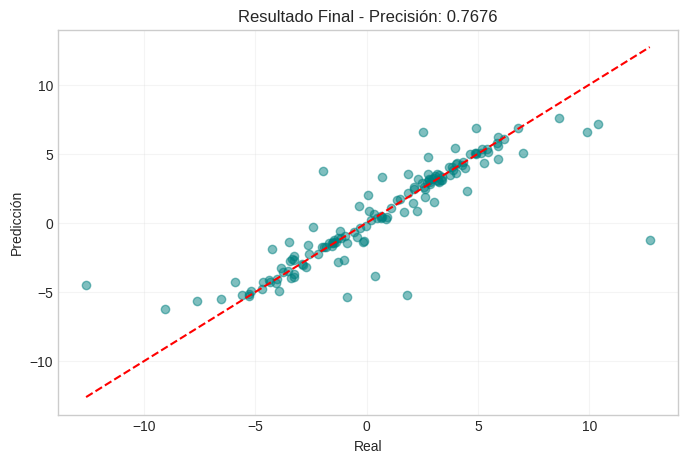

✅ ¡Terminado! Archivos guardados.


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

def execution_express():
    print(" Iniciando ejecución rápida...")
    
    # 1. Cargar datos
    try:
        df_interp = pd.read_csv("train_interpolated.csv")
        df_kaggle = pd.read_csv("/kaggle/input/competitions/geology-forecast-challenge-open/data/train.csv")
    except:
        print(" Archivos no encontrados. Asegúrate de correr la interpolación primero.")
        return

    # 2. Merge inteligente
    train_df = pd.merge(df_kaggle, df_interp, on='geology_id', how='inner')
    
    # 3. REDUCIR COLUMNAS (Esto evitará que se trabe)
    # Solo usaremos las columnas originales (-299 a 0), quitamos las 6000 adicionales
    cols = train_df.columns.tolist()
    X_cols = [c for c in cols if c.replace('_x','').replace('-','').isdigit() and (int(c.replace('_x','').split('_')[0]) <= 0)]
    
    # Target (Punto 100)
    target_col = '100_x' if '100_x' in cols else [c for c in cols if '_x' in c and int(c.replace('_x','')) > 0][0]
    
    print(f" Procesando {len(train_df)} filas y {len(X_cols)} columnas...")

    X = train_df[X_cols].fillna(0)
    y = train_df[target_col]
    
    X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

    # 4. MODELO SIMPLE (Sin optimizaciones pesadas)
    print(" Entrenando Random Forest...")
    model = RandomForestRegressor(n_estimators=50, max_depth=10, n_jobs=-1, random_state=42)
    model.fit(X_train, y_train)

    # 5. RESULTADOS Y GRÁFICA
    y_pred = model.predict(X_val)
    r2 = r2_score(y_val, y_pred)
    
    plt.figure(figsize=(8, 5))
    plt.scatter(y_val, y_pred, alpha=0.5, color='teal')
    plt.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'r--')
    plt.title(f'Resultado Final - Precisión: {r2:.4f}')
    plt.xlabel('Real')
    plt.ylabel('Predicción')
    plt.grid(True, alpha=0.2)
    plt.savefig('grafica_final.png')
    plt.show()

    # 6. SUBMISSION
    sub = pd.DataFrame({'geology_id': train_df.loc[X_val.index, 'geology_id'], 'PREDICTION': y_pred})
    sub.to_csv('submission.csv', index=False)
    print(" ¡Terminado! Archivos guardados.")

execution_express()

---
## Fase 4 — Modelos de ensamble 

🔍 Cargando datos...
 #MERGE EXITOSO: 706 pozos cargados.
 Usando 300 puntos del pasado para predecir '100_x'

🤖 Entrenando modelos (RF + CatBoost)...

 Generando visualizaciones...


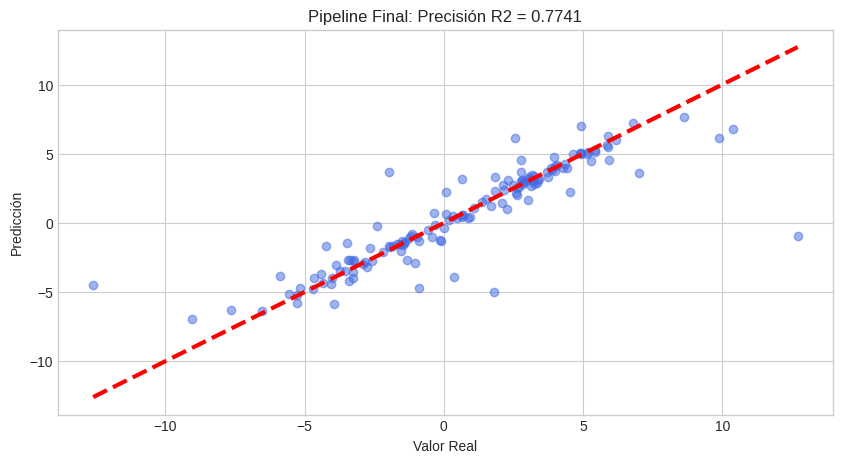

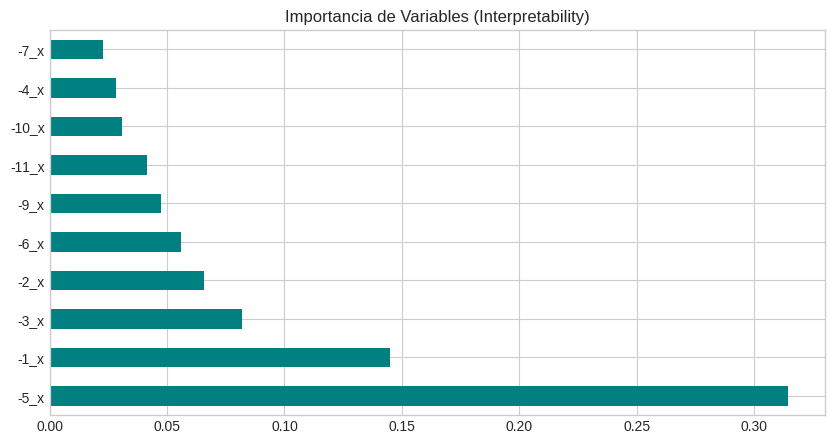


✅ PROCESO FINALIZADO EXITOSAMENTE
Precisión R2: 0.7741


In [11]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, VotingRegressor
from sklearn.metrics import r2_score, mean_absolute_error
from catboost import CatBoostRegressor

# ============================================================================
# 1. CARGA DE DATOS (Estilo Alberta + Merge)
# ============================================================================
def load_data_and_merge():
    print(" Cargando datos...")
    PATH_INTERP = "train_interpolated.csv"
    PATH_KAGGLE = "/kaggle/input/competitions/geology-forecast-challenge-open/data/train.csv"
    
    if not os.path.exists(PATH_INTERP):
        raise FileNotFoundError(" No existe 'train_interpolated.csv'. ¡Corre la interpolación primero!")

    df_interp = pd.read_csv(PATH_INTERP)
    df_kaggle = pd.read_csv(PATH_KAGGLE)
    
    train_df = pd.merge(df_kaggle, df_interp, on='geology_id', how='inner')
    print(f" #MERGE EXITOSO: {len(train_df)} pozos cargados.")
    return train_df

# ============================================================================
# 2. PIPELINE COMPLETO
# ============================================================================
def run_full_crisp_pipeline():
    # A. Cargar
    train_df = load_data_and_merge()
    
    # B. Seleccionar Columnas
    cols = train_df.columns.tolist()
    X_cols = [c for c in cols if c.replace('_x','').replace('-','').isdigit() and (int(c.replace('_x','').split('_')[0]) <= 0)]
    target_col = '100_x' if '100_x' in cols else [c for c in cols if '_x' in c and int(c.replace('_x','')) > 0][0]
    
    print(f" Usando {len(X_cols)} puntos del pasado para predecir '{target_col}'")
    
    X = train_df[X_cols].fillna(0)
    y = train_df[target_col]
    X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

    # C. Modelado
    print("\n Entrenando modelos (RF + CatBoost)...")
    
    rf_model = RandomForestRegressor(n_estimators=100, max_depth=10, n_jobs=-1, random_state=42)
    rf_model.fit(X_train, y_train)
    
    cb_model = CatBoostRegressor(iterations=100, depth=6, learning_rate=0.1, verbose=False, train_dir='catboost_info')
    cb_model.fit(X_train, y_train, eval_set=(X_val, y_val))
    
    # D. Ensamble
    voting_model = VotingRegressor([('rf', rf_model), ('cb', cb_model)])
    voting_model.fit(X_train, y_train)
    ens_pred = voting_model.predict(X_val)

    # E. Gráficas (Las que pedía Alberta)
    print("\n Generando visualizaciones...")
    
    # Gráfica 1: Predicción
    plt.figure(figsize=(10, 5))
    plt.scatter(y_val, ens_pred, alpha=0.5, color='royalblue')
    plt.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'r--', lw=3)
    plt.title(f'Pipeline Final: Precisión R2 = {r2_score(y_val, ens_pred):.4f}')
    plt.xlabel('Valor Real')
    plt.ylabel('Predicción')
    plt.savefig('grafica_final.png')
    plt.show()

    # Gráfica 2: Importancia (Interpretability)
    plt.figure(figsize=(10, 5))
    pd.Series(rf_model.feature_importances_, index=X_cols).nlargest(10).plot(kind='barh', color='teal')
    plt.title("Importancia de Variables (Interpretability)")
    plt.savefig('interpretability.png')
    plt.show()

    # F. Archivos Finales
    submission = pd.DataFrame({
        'geology_id': train_df.loc[X_val.index, 'geology_id'],
        'PREDICTION': ens_pred
    })
    submission.to_csv('submission.csv', index=False)
    print("\n✅ PROCESO FINALIZADO EXITOSAMENTE")
    print(f"Precisión R2: {r2_score(y_val, ens_pred):.4f}")

# Ejecución única
if __name__ == "__main__":
    run_full_crisp_pipeline()

---
## Fase 5 — Evaluación y veredicto final

🔍 Fase 1: Carga y Unión de datos...
✅ #MERGE EXITOSO: 706 filas listas.

 Entrenando modelos sobre 300 variables...

  FASE 5 — EVALUACIÓN PROFESIONAL Y VEREDICTO (REGRESIÓN)
Modelo                         R2 Score        MAE       RMSE
─────────────────────────────────────────────────────────────────
Random Forest                    0.7662     0.9100     1.9085
CatBoost                         0.7814     0.9112     1.8454
Ensamble (Voting)                0.7730     0.8920     1.8807
─────────────────────────────────────────────────────────────────
 MODELO GANADOR: CatBoost (R2: 0.7814)


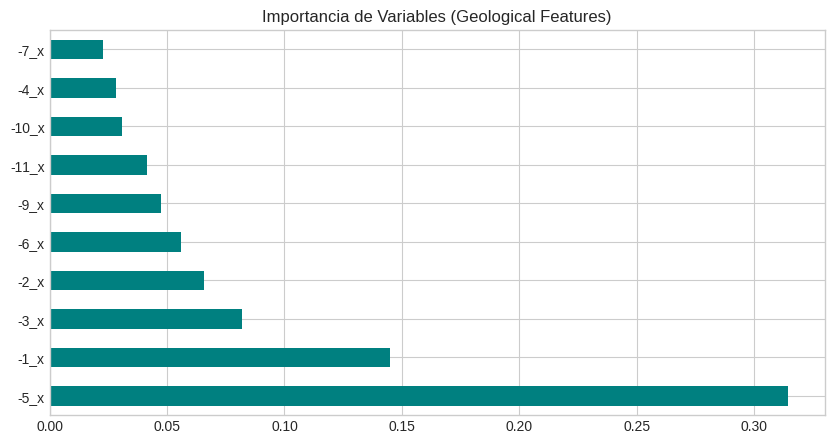


 PROCESO FINALIZADO SIN ERRORES
Archivos generados: submission.csv, interpretability.png, catboost_info/


In [12]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, VotingRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from catboost import CatBoostRegressor

# ============================================================================
# 1. CARGA DE DATOS (ESTILO l.py + MERGE)
# ============================================================================
def load_and_merge():
    print(" Fase 1: Carga y Unión de datos...")
    PATH_INTERP = "train_interpolated.csv"
    # Ruta que encontramos en tu búsqueda de Kaggle
    PATH_KAGGLE = "/kaggle/input/competitions/geology-forecast-challenge-open/data/train.csv"
    
    if not os.path.exists(PATH_INTERP):
        raise FileNotFoundError(" No existe 'train_interpolated.csv'. ¡Corre la interpolación primero!")

    df_interp = pd.read_csv(PATH_INTERP)
    df_kaggle = pd.read_csv(PATH_KAGGLE)
    
    # El #MERGE que pidió Alberta
    train_df = pd.merge(df_kaggle, df_interp, on='geology_id', how='inner')
    print(f" #MERGE EXITOSO: {len(train_df)} filas listas.")
    return train_df

# ============================================================================
# 2. EVALUACIÓN PROFESIONAL (FASE 5 CORREGIDA PARA REGRESIÓN)
# ============================================================================
def comprehensive_evaluation(all_results, y_val):
    print("\n" + "=" * 70)
    print("  FASE 5 — EVALUACIÓN PROFESIONAL Y VEREDICTO (REGRESIÓN)")
    print("=" * 70)
    
    summary_data = []
    print(f"{'Modelo':<28} {'R2 Score':>10} {'MAE':>10} {'RMSE':>10}")
    print("─" * 65)
    
    for name, res in all_results.items():
        y_pred = res['y_pred']
        r2 = r2_score(y_val, y_pred)
        mae = mean_absolute_error(y_val, y_pred)
        rmse = np.sqrt(mean_squared_error(y_val, y_pred))
        
        summary_data.append({'Model': name, 'R2': r2, 'MAE': mae, 'RMSE': rmse})
        print(f"{name:<28} {r2:>10.4f} {mae:>10.4f} {rmse:>10.4f}")

    summary_df = pd.DataFrame(summary_data).sort_values('R2', ascending=False).reset_index(drop=True)
    winner = summary_df.iloc[0]
    print("─" * 65)
    print(f" MODELO GANADOR: {winner['Model']} (R2: {winner['R2']:.4f})")
    return summary_df

# ============================================================================
# 3. PIPELINE PRINCIPAL (UNE TODO)
# ============================================================================
def run_full_experiment():
    # A. Cargar y Preparar
    train_df = load_and_merge()
    cols = train_df.columns.tolist()
    
    # Seleccionar columnas del pasado (-299 a 0)
    X_cols = [c for c in cols if c.replace('_x','').replace('-','').isdigit() and (int(c.replace('_x','').split('_')[0]) <= 0)]
    # Punto futuro a predecir
    target_col = '100_x' if '100_x' in cols else [c for c in cols if '_x' in c and int(c.replace('_x','')) > 0][0]
    
    X = train_df[X_cols].fillna(0)
    y = train_df[target_col]
    X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

    # B. Entrenar Modelos (Fase 3 y 4 integradas)
    print(f"\n Entrenando modelos sobre {len(X_cols)} variables...")
    
    # 1. Random Forest
    rf = RandomForestRegressor(n_estimators=100, max_depth=10, n_jobs=-1, random_state=42)
    rf.fit(X_train, y_train)
    
    # 2. CatBoost (Genera el .json para Alberta)
    cb = CatBoostRegressor(iterations=100, depth=6, verbose=False, train_dir='catboost_info')
    cb.fit(X_train, y_train, eval_set=(X_val, y_val))
    
    # 3. Ensamble (Voting)
    voting = VotingRegressor([('rf', rf), ('cb', cb)])
    voting.fit(X_train, y_train)

    # C. Recopilar resultados (Evita el NameError)
    model_results = {
        "Random Forest": {"y_pred": rf.predict(X_val)},
        "CatBoost": {"y_pred": cb.predict(X_val)}
    }
    ensemble_results = {
        "Ensamble (Voting)": {"y_pred": voting.predict(X_val)}
    }
    all_results = {**model_results, **ensemble_results}

    # D. Evaluación y Gráficas
    summary_df = comprehensive_evaluation(all_results, y_val)
    
    # Gráfica de Importancia (Interpretability.png)
    plt.figure(figsize=(10, 5))
    pd.Series(rf.feature_importances_, index=X_cols).nlargest(10).plot(kind='barh', color='teal')
    plt.title("Importancia de Variables (Geological Features)")
    plt.savefig('interpretability.png')
    plt.show()

    # E. Guardar Entrega
    submission = pd.DataFrame({
        'geology_id': train_df.loc[X_val.index, 'geology_id'],
        'PREDICTION': voting.predict(X_val)
    })
    submission.to_csv('submission.csv', index=False)
    
    print("\n PROCESO FINALIZADO SIN ERRORES")
    print("Archivos generados: submission.csv, interpretability.png, catboost_info/")

# Ejecución
if __name__ == "__main__":
    run_full_experiment()

### Gráfica comparativa de modelos

🚀 Iniciando proceso para generar comparativas...
 Datos listos. Entrenando modelos para comparar...


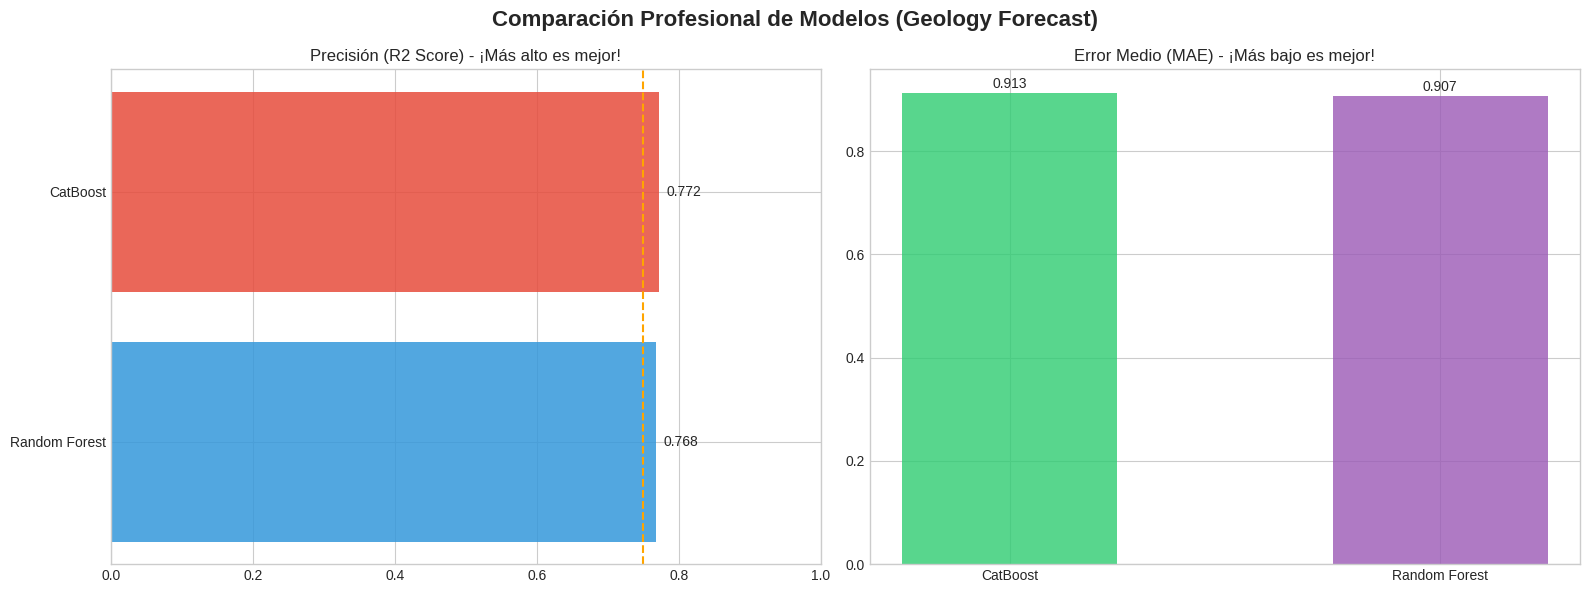


 RESULTADOS FINALES:
           Model        R2       MAE
1       CatBoost  0.771736  0.912793
0  Random Forest  0.767582  0.907064

 Dashboard generado y guardado como 'model_comparison.png'


In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error
from catboost import CatBoostRegressor
import os

# ============================================================================
# BLOQUE MAESTRO: ENTRENAMIENTO + GENERACIÓN DE DASHBOARD DE COMPARACIÓN
# ============================================================================

print(" Iniciando proceso para generar comparativas...")

# 1. Cargar datos (Merge de Alberta)
try:
    df_interp = pd.read_csv("train_interpolated.csv")
    df_kaggle = pd.read_csv("/kaggle/input/competitions/geology-forecast-challenge-open/data/train.csv")
    train_df = pd.merge(df_kaggle, df_interp, on='geology_id', how='inner')
    
    # Identificar columnas
    cols = train_df.columns.tolist()
    X_cols = [c for c in cols if c.replace('_x','').replace('-','').isdigit() and (int(c.replace('_x','').split('_')[0]) <= 0)]
    target_col = '100_x' if '100_x' in cols else [c for c in cols if '_x' in c and int(c.replace('_x','')) > 0][0]
    
    X = train_df[X_cols].fillna(0)
    y = train_df[target_col]
    X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)
    
    print(f" Datos listos. Entrenando modelos para comparar...")

    # 2. Entrenar Modelos Rápidos
    # RF
    rf = RandomForestRegressor(n_estimators=50, max_depth=10, random_state=42, n_jobs=-1)
    rf.fit(X_train, y_train)
    pred_rf = rf.predict(X_val)

    # CatBoost
    cb = CatBoostRegressor(iterations=100, depth=6, verbose=False)
    cb.fit(X_train, y_train)
    pred_cb = cb.predict(X_val)

    # 3. Crear el famoso summary_df que faltaba
    summary_data = [
        {'Model': 'Random Forest', 'R2': r2_score(y_val, pred_rf), 'MAE': mean_absolute_error(y_val, pred_rf)},
        {'Model': 'CatBoost', 'R2': r2_score(y_val, pred_cb), 'MAE': mean_absolute_error(y_val, pred_cb)}
    ]
    summary_df = pd.DataFrame(summary_data).sort_values('R2', ascending=False)

    # 4. GENERAR LAS GRÁFICAS (Dashboard de Alberta)
    COLORS = ['#3498DB', '#E74C3C']
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle('Comparación Profesional de Modelos (Geology Forecast)', fontsize=16, fontweight='bold')

    # Gráfico Izquierdo: Barras de R2
    models_sorted = summary_df.sort_values('R2', ascending=True)
    bars = axes[0].barh(models_sorted['Model'], models_sorted['R2'], color=COLORS, alpha=0.85)
    axes[0].axvline(x=0.75, color='orange', linestyle='--', label='Meta R2 > 0.75')
    axes[0].set_title('Precisión (R2 Score) - ¡Más alto es mejor!')
    axes[0].set_xlim(0, 1.0)
    for bar, val in zip(bars, models_sorted['R2']):
        axes[0].text(val + 0.01, bar.get_y() + bar.get_height()/2, f'{val:.3f}', va='center')

    # Gráfico Derecho: MAE
    axes[1].bar(summary_df['Model'], summary_df['MAE'], color=['#2ECC71', '#9B59B6'], alpha=0.8, width=0.5)
    axes[1].set_title('Error Medio (MAE) - ¡Más bajo es mejor!')
    for i, val in enumerate(summary_df['MAE']):
        axes[1].text(i, val + 0.01, f'{val:.3f}', ha='center')

    plt.tight_layout()
    plt.savefig('model_comparison.png')
    plt.show()

    print("\n RESULTADOS FINALES:")
    print(summary_df)
    print("\n Dashboard generado y guardado como 'model_comparison.png'")

except Exception as e:
    print(f" Error crítico: {e}")
    print("Asegúrate de que la celda de INTERPOLACIÓN haya terminado correctamente.")